# Étape 1 — Exploration des données (EDA)

**Objectif** : comprendre la structure, la qualité et les régularités du dataset brut de Zenith avant tout traitement.

**Entrée** : `data/raw/zenith_dataset_brut.csv` (≈ 68 000 transactions, 18 colonnes, août 2022 → juillet 2025).

**Sorties** :
- 15 figures dans `outputs/figures/eda_*.png`
- `outputs/tables/eda_summary.csv` — synthèse statistique
- `outputs/tables/eda_top20_*.csv` — tops produits / clients B2B

**Plan** :
1. Chargement et typage
2. Statistiques générales et valeurs manquantes
3. Distributions numériques
4. Distributions catégorielles
5. Détection visuelle des outliers
6. Analyse temporelle (CA, saisonnalité, dynamique inter-magasins)
7. Analyse client (B2B vs B2C)
8. Analyse produit (tops, saisonnalité par famille, marges)
9. Qualité des données (manquants, aberrants, doublons)
10. Conclusions et préconisations pour le prétraitement

## 0. Imports et configuration

In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
PALETTE = sns.color_palette('deep')
ZENITH_COLORS = {'primary': '#1f4e79', 'accent': '#ff6b6b', 'neutral': '#6c757d'}

ROOT = Path.cwd().resolve().parent
RAW = ROOT / 'data' / 'raw' / 'zenith_dataset_brut.csv'
FIG = ROOT / 'outputs' / 'figures'
TAB = ROOT / 'outputs' / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)

ROOT = C:\Users\victory\zenith-supply-chain


## 1. Chargement et typage explicite

On force les colonnes string en `string`, et on parse les dates en gérant les formats mixtes (ISO `YYYY-MM-DD` + européen `DD/MM/YYYY`).

In [2]:
dtypes = {c: 'string' for c in [
    'transaction_id','magasin','ville','produit_id','produit_nom','famille','marque',
    'origine_fournisseur','client_id','client_nom','type_client','mode_paiement']}
df = pd.read_csv(RAW, dtype=dtypes, low_memory=False)
iso = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
mask = iso.isna() & df['date'].notna()
if mask.any():
    iso.loc[mask] = pd.to_datetime(df.loc[mask, 'date'], format='%d/%m/%Y', errors='coerce')
df['date'] = iso
df.shape, df.dtypes

((68258, 18),
 transaction_id                 string
 date                   datetime64[us]
 magasin                        string
 ville                          string
 produit_id                     string
 produit_nom                    string
 famille                        string
 marque                         string
 origine_fournisseur            string
 prix_vente_unitaire           float64
 cout_achat_unitaire           float64
 quantite_vendue               float64
 montant_total                 float64
 client_id                      string
 client_nom                     string
 type_client                    string
 mode_paiement                  string
 stock_apres_vente             float64
 dtype: object)

## 2. Statistiques générales et valeurs manquantes

In [3]:
print(f"Lignes : {len(df):,}".replace(',', ' '))
print(f"Colonnes : {df.shape[1]}")
print(f"Période : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Mois couverts : {(df['date'].max() - df['date'].min()).days // 30}")
print(f"Produits uniques : {df['produit_id'].nunique()}")
print(f"Clients uniques : {df['client_id'].nunique()}")
print(f"Magasins : {df['magasin'].nunique()}")
print(f"Familles : {df['famille'].nunique()}")
print(f"Doublons exacts : {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)")
missing = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
print('\n% valeurs manquantes par colonne :')
missing

Lignes : 68 258
Colonnes : 18
Période : 2022-08-01 → 2025-07-31
Mois couverts : 36
Produits uniques : 250
Clients uniques : 3070
Magasins : 7
Familles : 25
Doublons exacts : 672 (0.98%)

% valeurs manquantes par colonne :


client_nom             3.74
mode_paiement          2.49
cout_achat_unitaire    1.99
marque                 1.49
stock_apres_vente      0.99
montant_total          0.49
client_id              0.49
produit_nom            0.49
famille                0.49
origine_fournisseur    0.49
type_client            0.49
prix_vente_unitaire    0.49
quantite_vendue        0.49
transaction_id         0.00
date                   0.00
ville                  0.00
produit_id             0.00
magasin                0.00
dtype: float64

## 3. Distributions numériques

Les distributions de `prix_vente_unitaire` et `montant_total` sont fortement asymétriques (log-scale).

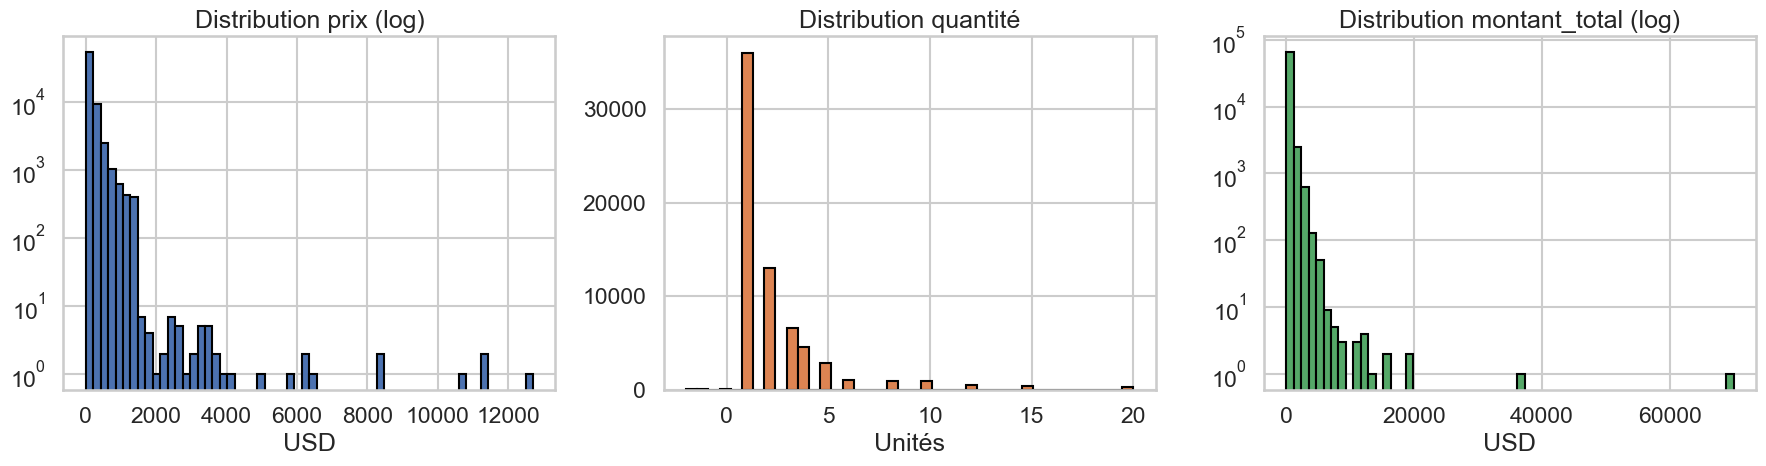

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df['prix_vente_unitaire'].dropna(), bins=60, color=PALETTE[0], edgecolor='black')
axes[0].set_yscale('log'); axes[0].set_title('Distribution prix (log)'); axes[0].set_xlabel('USD')
axes[1].hist(df['quantite_vendue'].dropna(), bins=40, color=PALETTE[1], edgecolor='black')
axes[1].set_title('Distribution quantité'); axes[1].set_xlabel('Unités')
axes[2].hist(df['montant_total'].dropna(), bins=60, color=PALETTE[2], edgecolor='black')
axes[2].set_yscale('log'); axes[2].set_title('Distribution montant_total (log)'); axes[2].set_xlabel('USD')
plt.tight_layout(); plt.savefig(FIG/'eda_01_distributions_numeriques.png', dpi=120, bbox_inches='tight'); plt.show()

## 4. Distributions catégorielles (top 15)

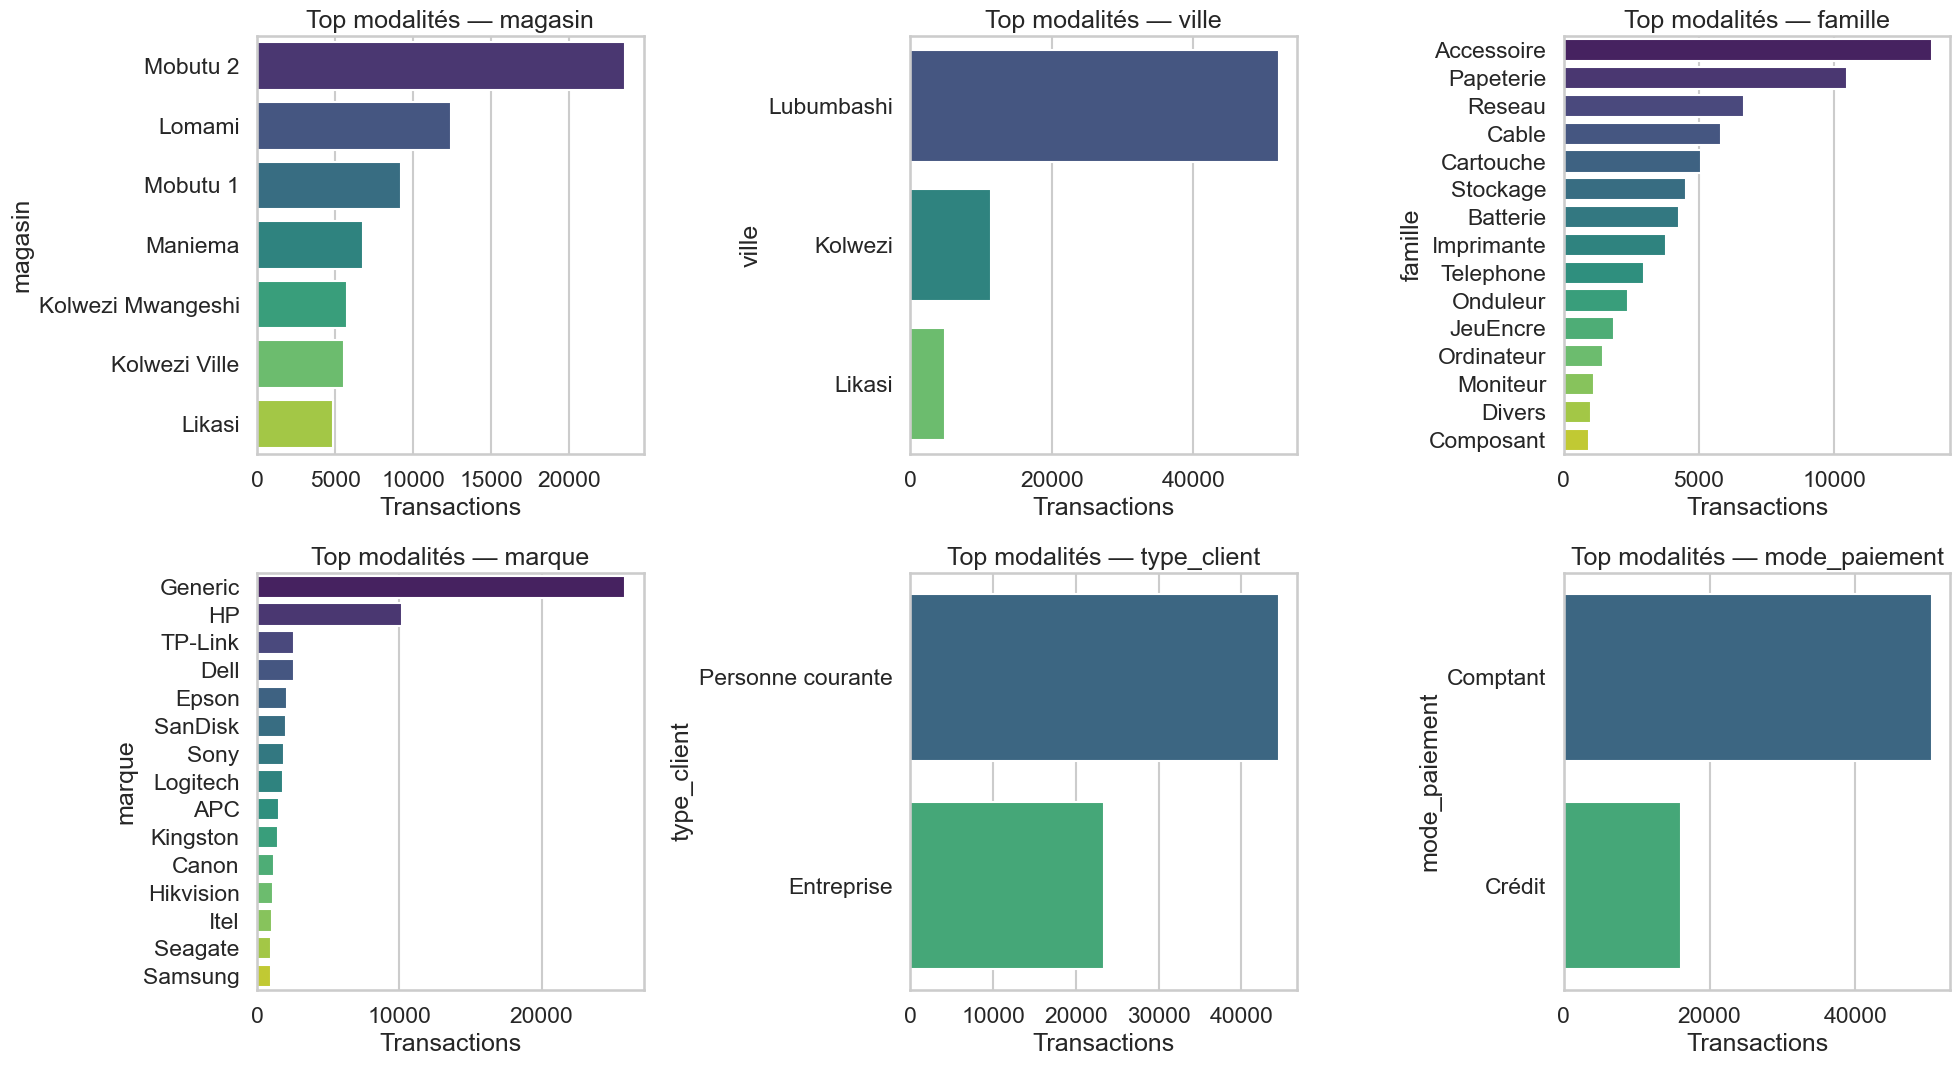

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, c in zip(axes.flatten(), ['magasin','ville','famille','marque','type_client','mode_paiement']):
    s = df[c].value_counts().head(15)
    sns.barplot(x=s.values, y=s.index, hue=s.index, ax=ax, palette='viridis', legend=False)
    ax.set_title(f'Top modalités — {c}'); ax.set_xlabel('Transactions')
plt.tight_layout(); plt.savefig(FIG/'eda_02_distributions_categorielles.png', dpi=120, bbox_inches='tight'); plt.show()

## 5. Détection visuelle des outliers (boxplots par famille)

Les boxplots révèlent les prix aberrants (saisies × 10) et les pics de quantité par famille.

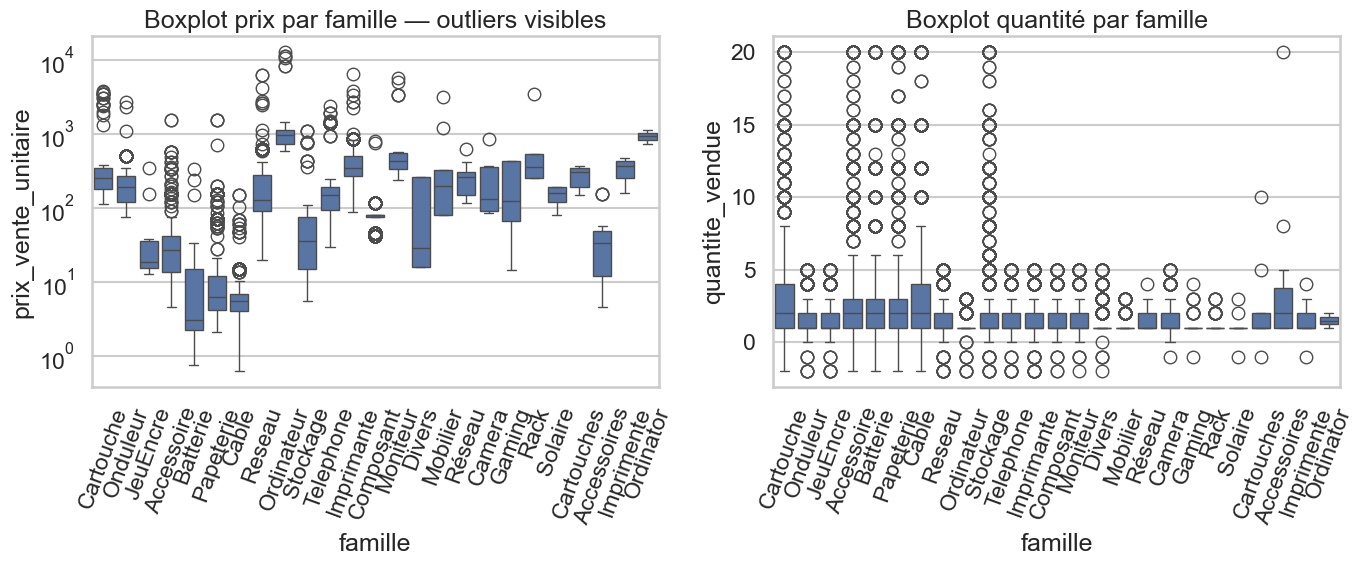

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x='famille', y='prix_vente_unitaire', ax=axes[0]); axes[0].set_yscale('log')
axes[0].set_title('Boxplot prix par famille — outliers visibles'); axes[0].tick_params(axis='x', rotation=70)
sns.boxplot(data=df, x='famille', y='quantite_vendue', ax=axes[1])
axes[1].set_title('Boxplot quantité par famille'); axes[1].tick_params(axis='x', rotation=70)
plt.tight_layout(); plt.savefig(FIG/'eda_03_outliers_boxplots.png', dpi=120, bbox_inches='tight'); plt.show()

## 6. Analyse temporelle

On observe : (a) une croissance moyenne du CA, (b) une saisonnalité août-septembre (rentrée scolaire RDC), (c) un creux en avril (saison des pluies), (d) la bascule **Lomami → Mobutu 2** sur 2024-2025.

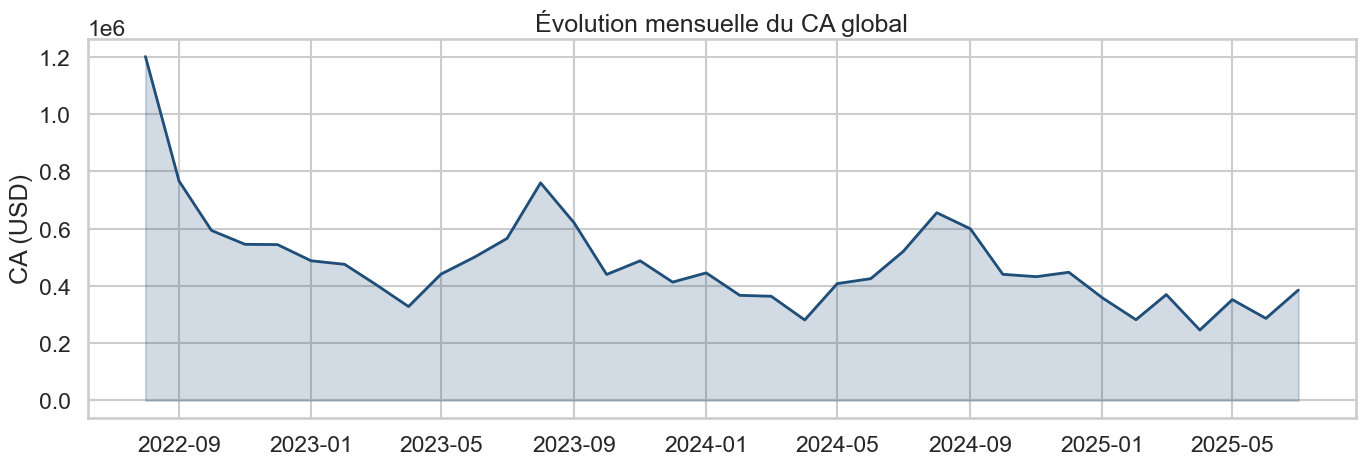

In [7]:
d2 = df.dropna(subset=['date','montant_total']).copy()
d2['annee'] = d2['date'].dt.year; d2['mois'] = d2['date'].dt.month
d2['mois_periode'] = d2['date'].dt.to_period('M').dt.to_timestamp()
d2['jour_semaine'] = d2['date'].dt.day_name()

ca_mensuel = d2.groupby('mois_periode')['montant_total'].sum()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ca_mensuel.index, ca_mensuel.values, color=ZENITH_COLORS['primary'], linewidth=2)
ax.fill_between(ca_mensuel.index, ca_mensuel.values, alpha=0.2, color=ZENITH_COLORS['primary'])
ax.set_title('Évolution mensuelle du CA global'); ax.set_ylabel('CA (USD)')
plt.tight_layout(); plt.savefig(FIG/'eda_04_ca_mensuel_global.png', dpi=120, bbox_inches='tight'); plt.show()

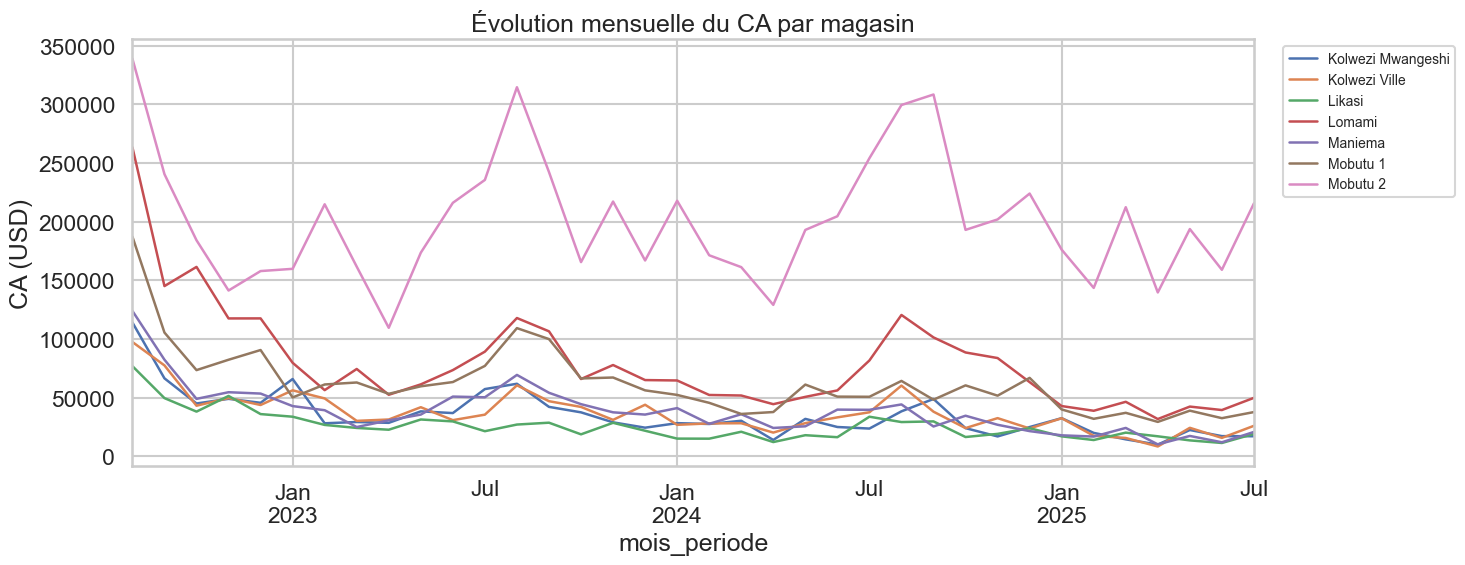

In [8]:
ca_mag = d2.groupby(['mois_periode','magasin'])['montant_total'].sum().unstack()
fig, ax = plt.subplots(figsize=(15, 6))
ca_mag.plot(ax=ax, linewidth=1.8)
ax.set_title('Évolution mensuelle du CA par magasin'); ax.set_ylabel('CA (USD)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout(); plt.savefig(FIG/'eda_05_ca_mensuel_par_magasin.png', dpi=120, bbox_inches='tight'); plt.show()

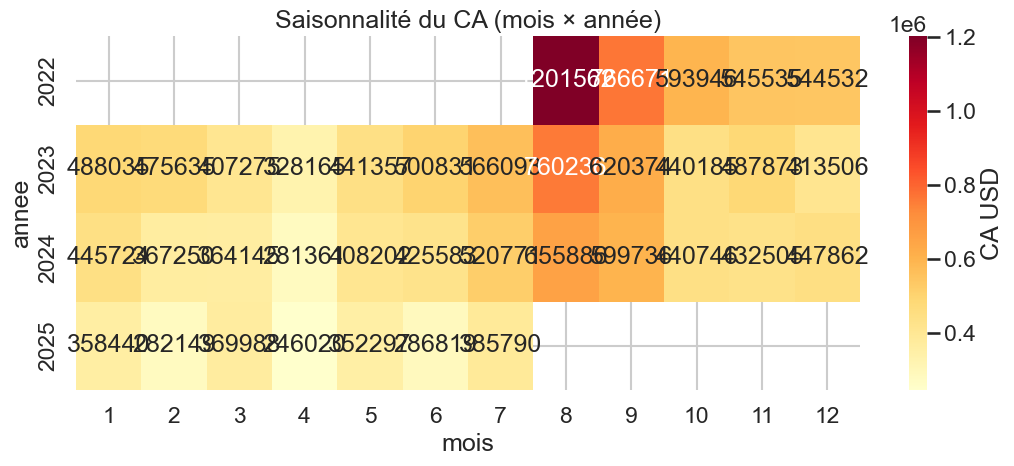

In [9]:
pivot = d2.groupby(['annee','mois'])['montant_total'].sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label':'CA USD'})
ax.set_title('Saisonnalité du CA (mois × année)')
plt.tight_layout(); plt.savefig(FIG/'eda_06_saisonnalite_heatmap.png', dpi=120, bbox_inches='tight'); plt.show()

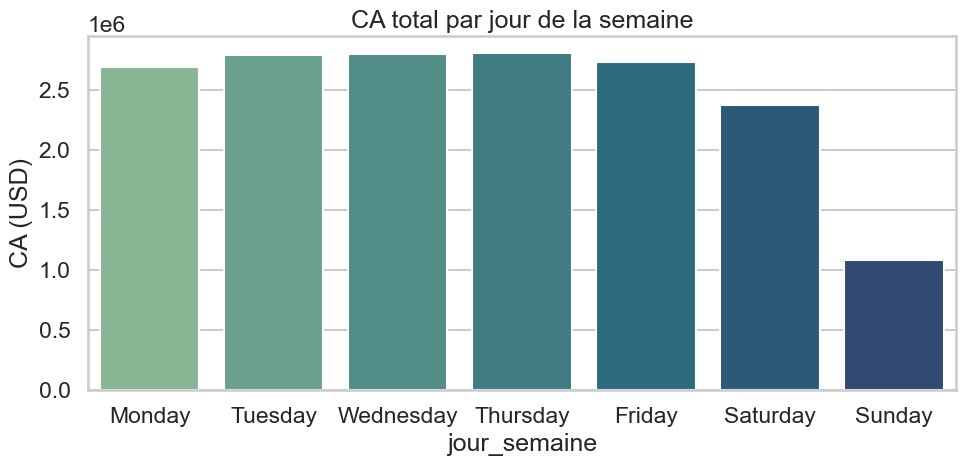

In [10]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
js = d2.groupby('jour_semaine')['montant_total'].sum().reindex(order)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=js.index, y=js.values, hue=js.index, ax=ax, palette='crest', legend=False)
ax.set_title('CA total par jour de la semaine'); ax.set_ylabel('CA (USD)')
plt.tight_layout(); plt.savefig(FIG/'eda_07_ca_par_jour_semaine.png', dpi=120, bbox_inches='tight'); plt.show()

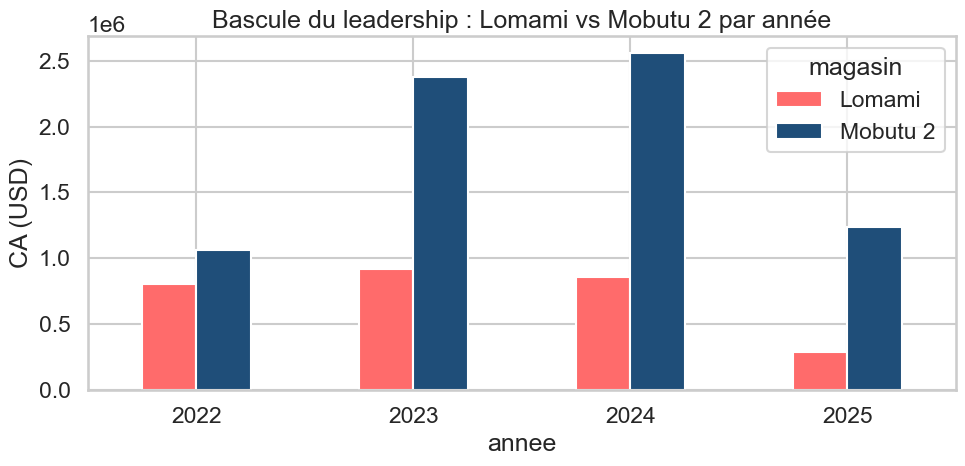

In [11]:
dyn = (d2[d2['magasin'].isin(['Lomami','Mobutu 2'])]
       .groupby([d2['date'].dt.year.rename('annee'),'magasin'])['montant_total'].sum().unstack())
fig, ax = plt.subplots(figsize=(10, 5))
dyn.plot(kind='bar', ax=ax, color=[ZENITH_COLORS['accent'], ZENITH_COLORS['primary']])
ax.set_title('Bascule du leadership : Lomami vs Mobutu 2 par année'); ax.set_ylabel('CA (USD)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIG/'eda_08_dynamique_lomami_mobutu2.png', dpi=120, bbox_inches='tight'); plt.show()

## 7. Analyse client (B2B vs B2C)

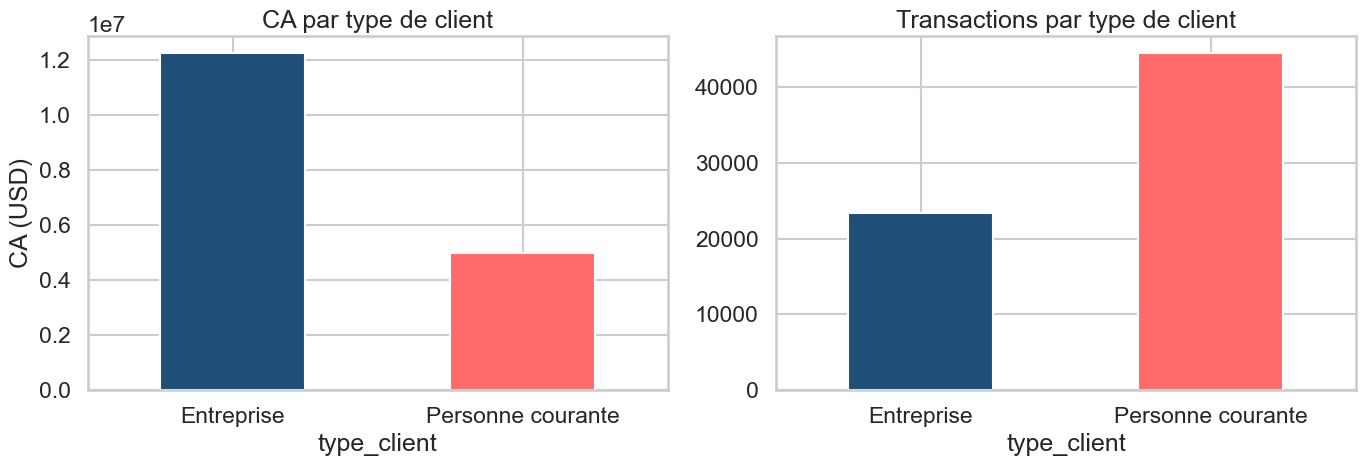

                            ca  n_transactions  n_clients
type_client                                              
Entreprise         12265477.38           23414         70
Personne courante   4987607.62           44507       3000


In [12]:
type_ca = d2.dropna(subset=['type_client']).groupby('type_client').agg(
    ca=('montant_total','sum'),
    n_transactions=('transaction_id','count'),
    n_clients=('client_id','nunique'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_ca['ca'].plot(kind='bar', ax=axes[0], color=[ZENITH_COLORS['primary'], ZENITH_COLORS['accent']])
axes[0].set_title('CA par type de client'); axes[0].set_ylabel('CA (USD)'); axes[0].tick_params(axis='x', rotation=0)
type_ca['n_transactions'].plot(kind='bar', ax=axes[1], color=[ZENITH_COLORS['primary'], ZENITH_COLORS['accent']])
axes[1].set_title('Transactions par type de client'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIG/'eda_09_clients_par_type.png', dpi=120, bbox_inches='tight'); plt.show()
print(type_ca)

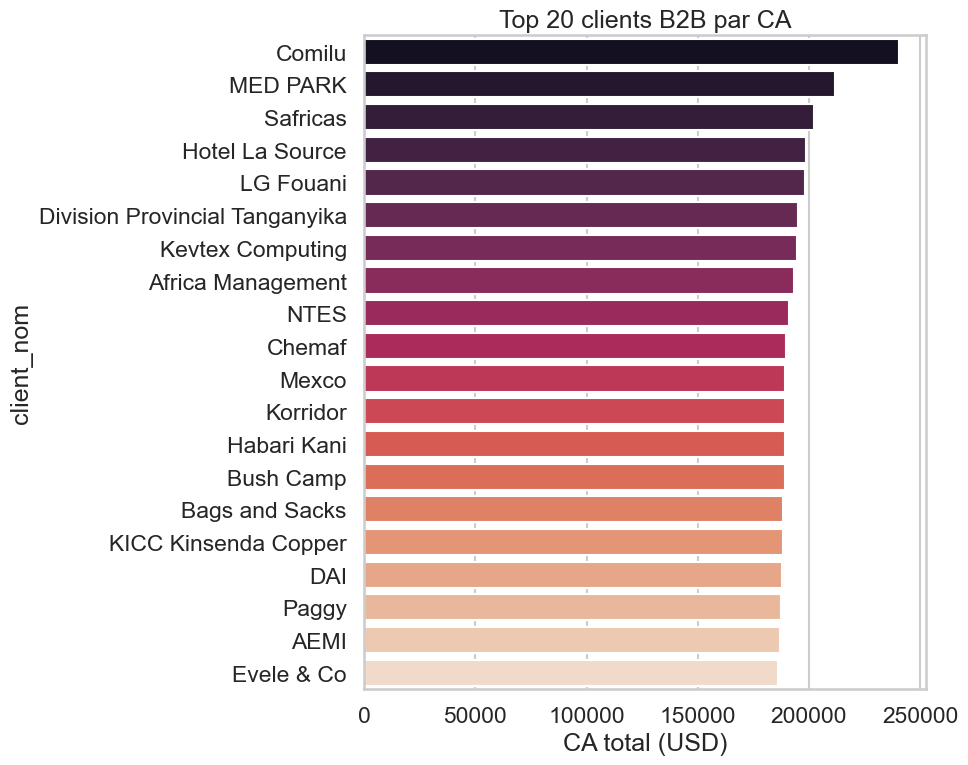

In [13]:
b2b = d2[d2['type_client']=='Entreprise']
top20 = b2b.groupby('client_nom')['montant_total'].sum().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, ax=ax, palette='rocket', legend=False)
ax.set_title('Top 20 clients B2B par CA'); ax.set_xlabel('CA total (USD)')
plt.tight_layout(); plt.savefig(FIG/'eda_10_top20_clients_b2b.png', dpi=120, bbox_inches='tight'); plt.show()
top20.to_csv(TAB/'eda_top20_clients_b2b.csv', header=['ca_usd'])

## 8. Analyse produit

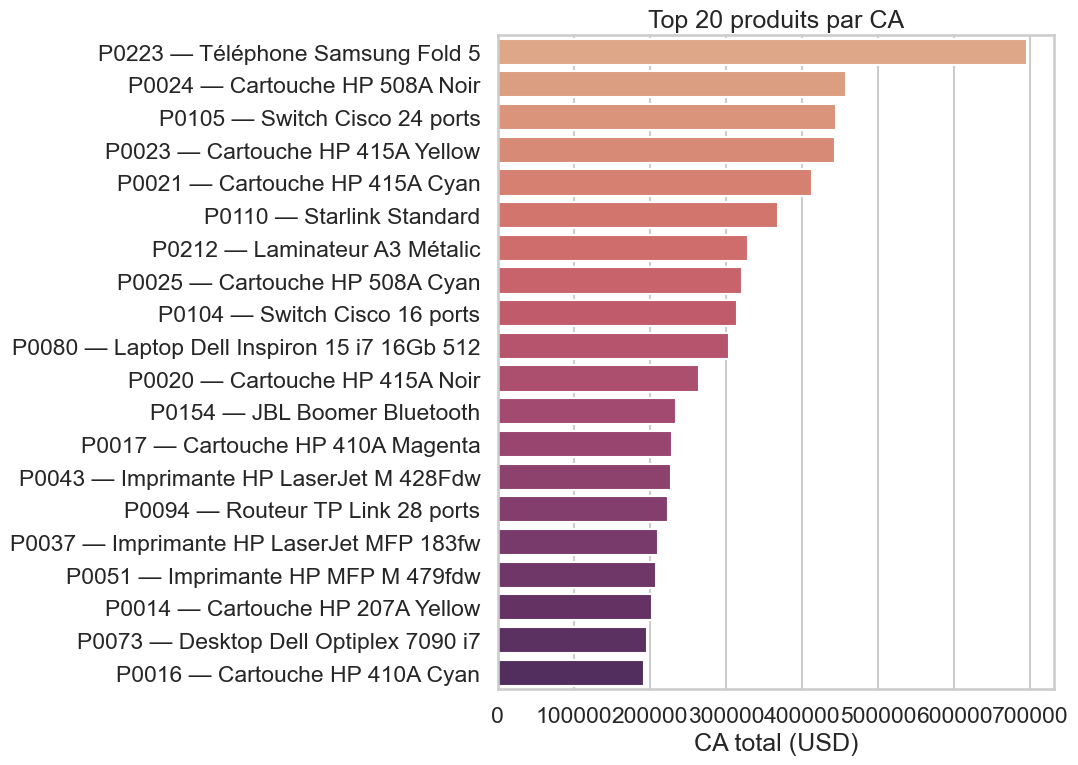

In [14]:
top20p = d2.dropna(subset=['produit_id']).groupby(['produit_id','produit_nom'])['montant_total'].sum().sort_values(ascending=False).head(20)
labels = [f'{a} — {b[:35]}' for a,b in top20p.index]
fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(x=top20p.values, y=labels, hue=labels, ax=ax, palette='flare', legend=False)
ax.set_title('Top 20 produits par CA'); ax.set_xlabel('CA total (USD)')
plt.tight_layout(); plt.savefig(FIG/'eda_11_top20_produits_ca.png', dpi=120, bbox_inches='tight'); plt.show()
top20p.to_csv(TAB/'eda_top20_produits.csv')

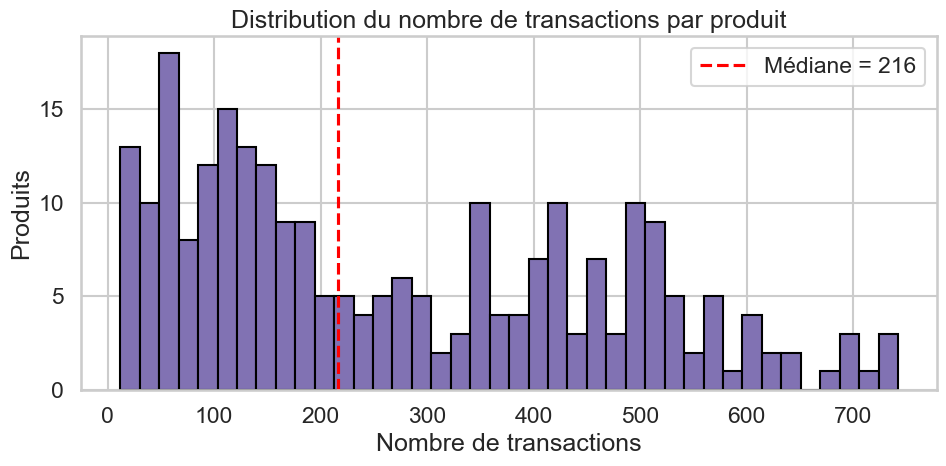

In [15]:
n_tx = d2.groupby('produit_id')['transaction_id'].count()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(n_tx.values, bins=40, color=PALETTE[4], edgecolor='black')
ax.axvline(n_tx.median(), color='red', linestyle='--', label=f'Médiane = {int(n_tx.median())}')
ax.set_title('Distribution du nombre de transactions par produit'); ax.set_xlabel('Nombre de transactions'); ax.set_ylabel('Produits'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'eda_12_distribution_transactions_par_produit.png', dpi=120, bbox_inches='tight'); plt.show()

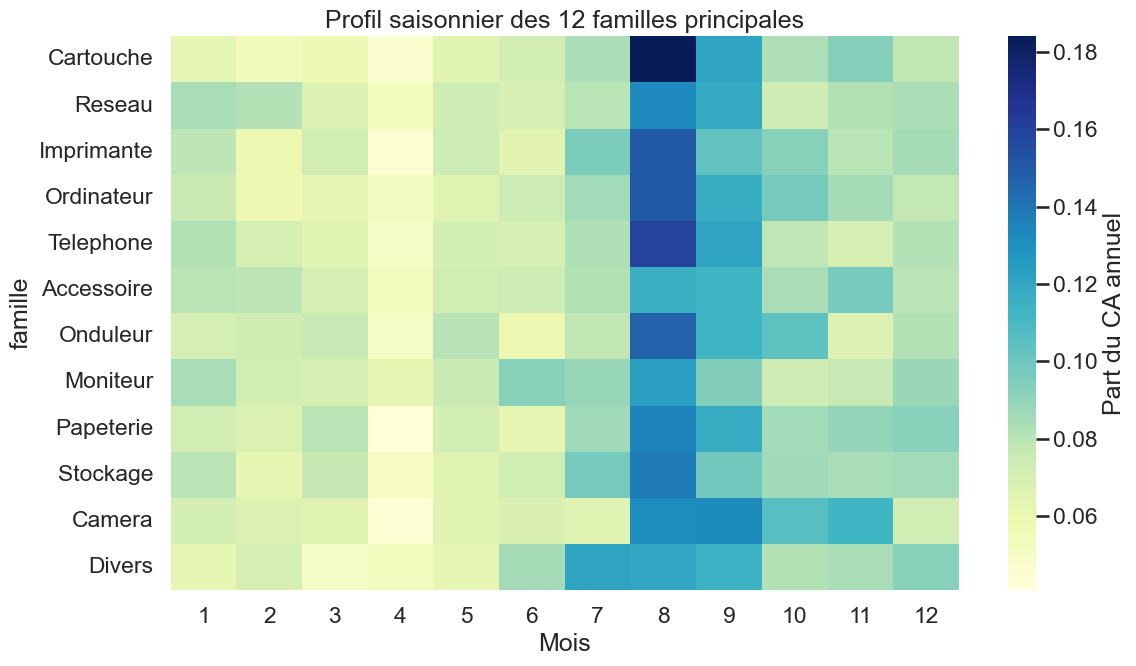

In [16]:
fam_mois = (d2.dropna(subset=['famille']).assign(mois=d2['date'].dt.month)
             .groupby(['famille','mois'])['montant_total'].sum().unstack().fillna(0))
fam_norm = fam_mois.div(fam_mois.sum(axis=1), axis=0)
top_fam = fam_mois.sum(axis=1).sort_values(ascending=False).head(12).index
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(fam_norm.loc[top_fam], cmap='YlGnBu', cbar_kws={'label':'Part du CA annuel'})
ax.set_title('Profil saisonnier des 12 familles principales'); ax.set_xlabel('Mois')
plt.tight_layout(); plt.savefig(FIG/'eda_13_saisonnalite_familles.png', dpi=120, bbox_inches='tight'); plt.show()

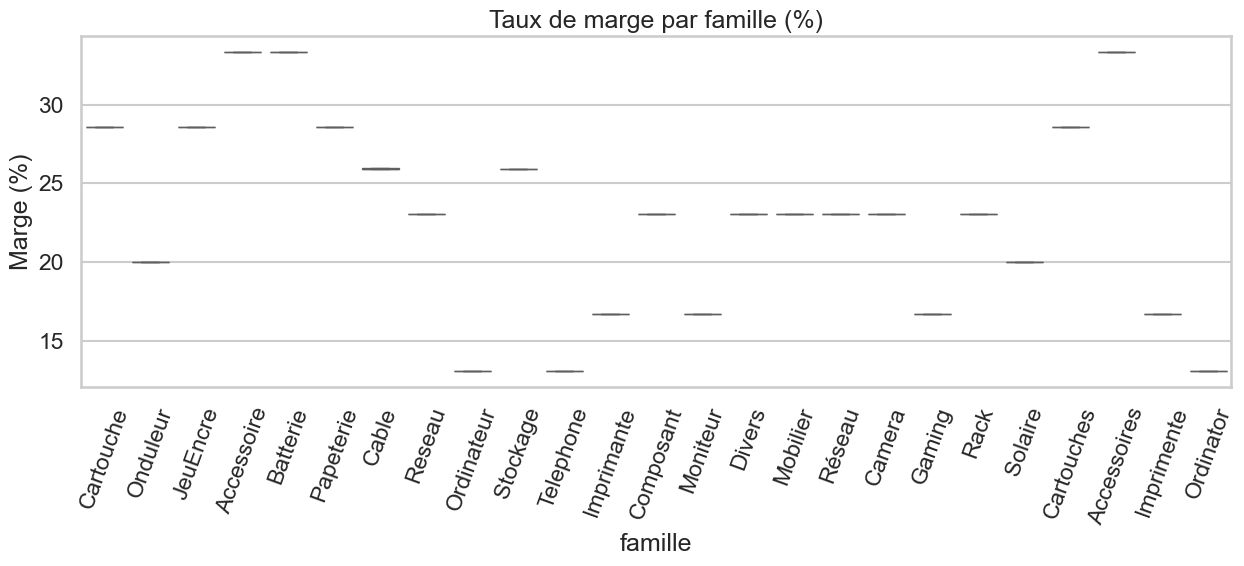

In [17]:
marges = d2.assign(marge_pct=(d2['prix_vente_unitaire']-d2['cout_achat_unitaire'])/d2['prix_vente_unitaire']*100)
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=marges, x='famille', y='marge_pct', hue='famille', palette='Set3', showfliers=False, legend=False, ax=ax)
ax.set_title('Taux de marge par famille (%)'); ax.tick_params(axis='x', rotation=70); ax.set_ylabel('Marge (%)')
plt.tight_layout(); plt.savefig(FIG/'eda_14_marges_par_famille.png', dpi=120, bbox_inches='tight'); plt.show()

## 9. Qualité des données (récap)

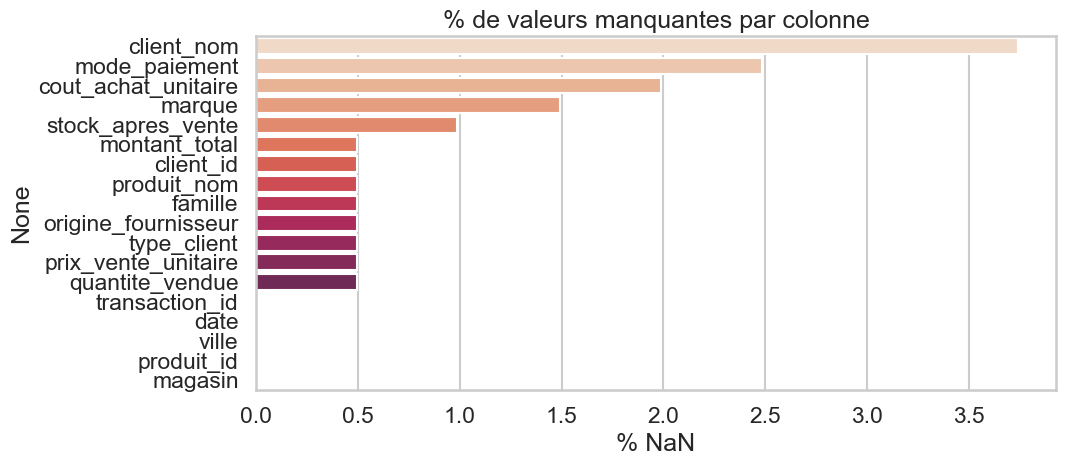

Doublons : 672
Prix aberrants (> 5× médiane famille) : 3323
Quantités ≤ 0 : 342


In [18]:
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index, ax=ax, palette='rocket_r', legend=False)
ax.set_title('% de valeurs manquantes par colonne'); ax.set_xlabel('% NaN')
plt.tight_layout(); plt.savefig(FIG/'eda_15_valeurs_manquantes.png', dpi=120, bbox_inches='tight'); plt.show()

med = df.groupby('famille')['prix_vente_unitaire'].transform('median')
n_aberrants = int(((df['prix_vente_unitaire'] > 5*med) & med.notna()).sum())
n_neg = int((df['quantite_vendue']<=0).sum())
print(f"Doublons : {df.duplicated().sum()}")
print(f"Prix aberrants (> 5× médiane famille) : {n_aberrants}")
print(f"Quantités ≤ 0 : {n_neg}")

## 10. Conclusions et préconisations

**Constats** :
1. **Volume** : 68 258 transactions sur 36 mois, 250 produits, 3 070 clients (dont ~70 B2B identifiés), 7 magasins sur 3 villes (Lubumbashi, Kolwezi, Likasi).
2. **Asymétrie commerciale** : la classe B2B représente ≈ **71 % du CA** alors qu'elle ne compte que ~70 clients (loi de Pareto très marquée).
3. **Saisonnalité forte** : pic en **août-septembre** (rentrée scolaire/académique RDC), creux en avril (saison des pluies).
4. **Dynamique inter-magasins** : Mobutu 2 domine Lomami sur l’ensemble de la période 2022-2025, avec un écart particulièrement marqué en 2023 et 2024.**.
5. **Imperfections du dataset (confirmées) :
    - **672 doublons exacts** (0.98 %)
    - **3 323 prix aberrants** (> 5× médiane famille), dont une partie est manifestement une erreur de saisie × 10
    - **342 quantités négatives ou nulles** (retours)
    - **341 dates** au format `DD/MM/YYYY` au lieu de `YYYY-MM-DD`
    - Manquants variables : `client_nom` 3.7 %, `cout_achat_unitaire` 2 %, `mode_paiement` 2.5 %
    - Fautes de frappe famille (`Cartouches`, `Imprimente`, `Ordinator`, etc.) — à harmoniser

**Préconisations pour l'Étape 2 (Prétraitement)** :
- Uniformiser les dates en `YYYY-MM-DD` (parseur multi-format).
- Dédoublonner sur la clé (`transaction_id`, `date`, `produit_id`, `client_id`).
- Corriger les prix > 10× médiane famille par `/ 10`, et imputer les autres par la médiane famille.
- Isoler les retours (`quantite_vendue ≤ 0`) dans une table séparée `retours.csv` (analyse à part).
- Normaliser les libellés famille via dictionnaire de correspondance.
- Imputer `cout_achat_unitaire` à partir de la marge moyenne par famille quand absent.
- Construire les features dérivées (temporelles cycliques, agrégations produit, financières).